# CNN (5-Conv) + mRMR + SVM Hybrid
**Pipeline:** Custom 5-layer CNN -> 256-d FC embeddings -> mRMR feature selection (K=64) -> SVM classifier  
All outputs saved to `CNN5_May11_Results/`


In [1]:
# ================================================
# Cell 1 — Imports & Config
# ================================================
# ── Standard library and scientific computing ─────────────────
# os/numpy/pandas/matplotlib/tqdm: I/O, arrays, results, charts
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ── PyTorch and sklearn pipeline ───────────────────────────────
# torch/nn/optim/F: model, layers, optimiser, activations
# sklearn: SVM, StandardScaler, mRMR, joblib
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets


# Evaluation, StandardScaler, SVC, mutual_info_classif, dump
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from joblib import dump


# ── Paths ──────────────────────────────────────────────────────
# Same pre-split dataset as all other CNN experiments.
# ── Paths ──────────────────────────────────────
BASE_DATASET = "/home/jenarththan/Desktop/FYP/May11/Dataset"
TRAIN_PATH   = os.path.join(BASE_DATASET, "Training")
VAL_PATH     = os.path.join(BASE_DATASET, "Validation")
TEST_PATH    = os.path.join(BASE_DATASET, "Testing")

NOTEBOOK_DIR = "/home/jenarththan/Desktop/FYP/May11/Notebooks/Custom"
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, "CNN5_May11_Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ── Hyperparameters ────────────────────────────────────────────
# LR=1e-4    : trained from scratch
# K_MRMR=64  : same as CNN4 — 64 features from 256-d embedding.
#              Backbone is 512-d but fc1 bottlenecks to 256-d first.
# No ImageNet normalisation — Resize + ToTensor only.
# ── Hyperparameters ─────────────────────────────
CLASS_NAMES     = ['0', '100', '500', '1000', '1500', '2000']
NUM_CLASSES     = len(CLASS_NAMES)
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 50
PATIENCE        = 5
MIN_EPOCHS_BEFORE_STOP = 20
LR              = 1e-4
SEED            = 42
TRAIN_PER_CLASS = 1750
VAL_PER_CLASS   = 250
K_MRMR          = 64
NUM_WORKERS     = 0


# CUDA required; cudnn.benchmark=True for fixed input size
# ── CUDA setup ──────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Check nvidia-smi, then re-run.")

DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# Fix all random seeds for full reproducibility
rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


Output directory: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN5_May11_Results
GPU : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


In [2]:
# ================================================
# Cell 2 — Dataset Loading
# ================================================
# Enforces numeric class order: 0, 100, 500, 1000, 1500, 2000
class OrderedImageFolder(datasets.ImageFolder):
    """ImageFolder with a fixed class order instead of alphabetical."""
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {c: i for i, c in enumerate(classes)}
        missing = [c for c in classes if c not in os.listdir(directory)]
        if missing:
            raise FileNotFoundError(f"Missing class folders in {directory}: {missing}")
        return classes, class_to_idx


# Resize + ToTensor only — no ImageNet normalisation or augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


# Load all three pre-split dataset folders
# Load directly from pre-split folders (no Subset needed)
train_ds = OrderedImageFolder(root=TRAIN_PATH, transform=transform)
val_ds   = OrderedImageFolder(root=VAL_PATH,   transform=transform)
test_ds  = OrderedImageFolder(root=TEST_PATH,  transform=transform)

assert train_ds.classes == CLASS_NAMES, "Train class order mismatch!"
assert val_ds.classes   == CLASS_NAMES, "Val class order mismatch!"
assert test_ds.classes  == CLASS_NAMES, "Test class order mismatch!"

print(f"Classes    : {CLASS_NAMES}")
print(f"Train      : {len(train_ds):,} images  ({len(train_ds)//NUM_CLASSES} per class)")
print(f"Validation : {len(val_ds):,} images  ({len(val_ds)//NUM_CLASSES} per class)")
print(f"Test       : {len(test_ds):,} images  ({len(test_ds)//NUM_CLASSES} per class)")


# train_loader: shuffled | val/test loaders: unshuffled
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Data loaders ready.")


Classes    : ['0', '100', '500', '1000', '1500', '2000']
Train      : 10,500 images  (1750 per class)
Validation : 1,500 images  (250 per class)
Test       : 3,000 images  (500 per class)
Data loaders ready.


In [3]:
# ================================================
# Cell 3 — Model: Custom 5-Conv CNN
# ================================================
# Spatial flow (224x224 input):
#   conv1 + pool -> 112
#   conv2 + pool ->  56
#   conv3 + pool ->  28
#   conv4 + pool ->  14
#   conv5 + pool ->   7  -> AdaptiveAvgPool(1,1)
# Channel flow: 3 -> 32 -> 64 -> 128 -> 256 -> 512
# FC: 512 -> 256 (256-d embedding for SVM) -> num_classes
# ================================================
# ── Model architecture — Custom5CNN ────────────────────────────
# Extends CNN4 with a fifth convolutional layer, reaching 512 channels.
# Spatial flow: 224->112->56->28->14->7 (pool after each conv),
#               then AdaptiveAvgPool(1,1) -> (B, 512)
# Channel flow: 3 -> 32 -> 64 -> 128 -> 256 -> 512
#
# Key design choice: fc1 reduces 512-d backbone features to 256-d
# (a bottleneck that compresses the larger feature space before SVM).
# Dropout increased to 0.5 (vs 0.4 for CNN2-CNN4) — stronger
# regularisation needed as network depth and parameter count grow.
# K_MRMR=64 applied to the 256-d embedding (same ratio as CNN4).
class Custom5CNN(nn.Module):
    def __init__(self, num_classes=6, p_drop=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32,  64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool          = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout       = nn.Dropout(p_drop)
        self.fc1           = nn.Linear(512, 256)         # 256-d embedding
        self.fc2           = nn.Linear(256, num_classes)
        self.feature_maps  = None

    def forward(self, x, return_embedding=False):
        x = self.pool(F.relu(self.conv1(x)))             # 224 -> 112
        x = self.pool(F.relu(self.conv2(x)))             # 112 ->  56
        x = self.pool(F.relu(self.conv3(x)))             #  56 ->  28
        x = self.pool(F.relu(self.conv4(x)))             #  28 ->  14
        x = self.pool(F.relu(self.conv5(x)))             #  14 ->   7
        self.feature_maps = x
        x   = self.adaptive_pool(x).view(x.size(0), -1)  # (B, 512)
        emb = F.relu(self.fc1(x))                        # (B, 256) embedding
        logits = self.fc2(self.dropout(emb))
        if return_embedding:
            return logits, emb
        return logits

model     = Custom5CNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom5CNN — trainable parameters: {total_params:,}")


Custom5CNN — trainable parameters: 1,701,446


/tmp/ipykernel_29116/1708032374.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp        = torch.cuda.amp.GradScaler()


Epoch 1/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_29116/1708032374.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_29116/1708032374.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 49/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 49]  Train Acc: 0.7310  Val Acc: 0.7053  Train Loss: 0.6260  Val Loss: 0.6644


Epoch 50/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 50/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 50]  Train Acc: 0.7306  Val Acc: 0.7220  Train Loss: 0.6286  Val Loss: 0.6394

Training complete. Best model -> /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN5_May11_Results/best_custom_5cnn_model.pth


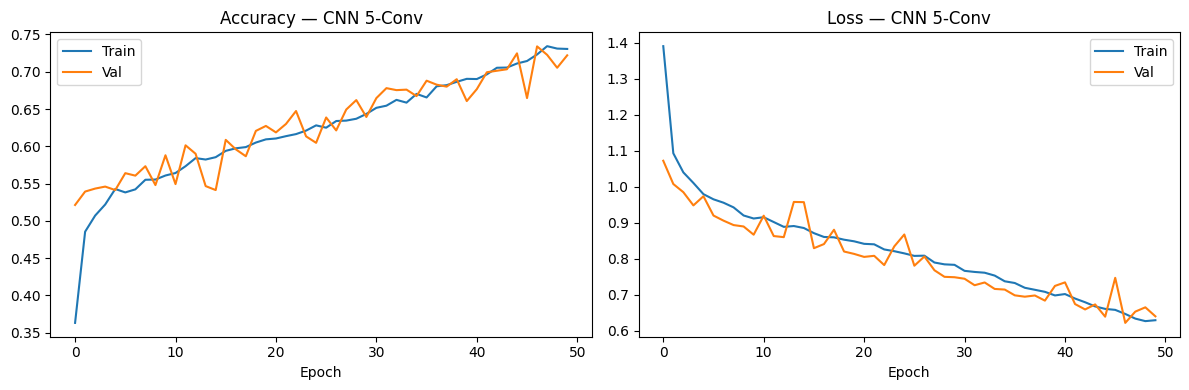

Training curves saved.


In [4]:
# ================================================
# Cell 4 — Training  (AMP + early stopping + save best)
# ================================================
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_custom_5cnn_model.pth")

# AMP: float16 training with GradScaler
scaler_amp        = torch.cuda.amp.GradScaler()

# Track best val_loss; save model whenever it improves
best_val_loss     = float('inf')
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []


# ── Training loop: train -> validate -> early stop -> save best ──
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


# Plot and save training/validation accuracy and loss per epoch
# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label='Train'); axes[0].plot(val_acc_hist, label='Val')
axes[0].set_title("Accuracy — CNN 5-Conv"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(train_loss_hist, label='Train'); axes[1].plot(val_loss_hist, label='Val')
axes[1].set_title("Loss — CNN 5-Conv"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")


     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/94 [00:00<?, ?it/s]

     0             0           500       NO 
     1             0             0       YES
     2             0           500       NO 
     3             0             0       YES
     4             0             0       YES
     5             0           500       NO 
     6             0             0       YES
     7             0           500       NO 
     8             0           500       NO 
     9             0             0       YES
    10             0             0       YES
    11             0           500       NO 
    12             0           500       NO 
    13             0           500       NO 
    14             0           500       NO 
    15             0             0       YES
    16             0           500       NO 
    17             0             0       YES
    18             0             0       YES
    19             0           500       NO 
    20             0             0       YES
    21             0           500       NO 
    22    

/tmp/ipykernel_29116/306566726.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    96             0           500       NO 
    97             0             0       YES
    98             0             0       YES
    99             0           500       NO 
   100             0             0       YES
   101             0             0       YES
   102             0             0       YES
   103             0             0       YES
   104             0             0       YES
   105             0             0       YES
   106             0             0       YES
   107             0           500       NO 
   108             0           500       NO 
   109             0           500       NO 
   110             0           500       NO 
   111             0             0       YES
   112             0           500       NO 
   113             0             0       YES
   114             0             0       YES
   115             0           500       NO 
   116             0           500       NO 
   117             0             0       YES
   118    

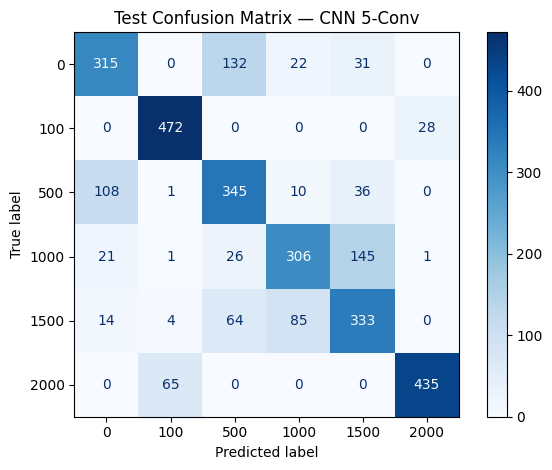


Classification Report — CNN 5-Conv:
              precision    recall  f1-score   support

           0     0.6878    0.6300    0.6576       500
         100     0.8692    0.9440    0.9051       500
         500     0.6085    0.6900    0.6467       500
        1000     0.7234    0.6120    0.6631       500
        1500     0.6110    0.6660    0.6373       500
        2000     0.9375    0.8700    0.9025       500

    accuracy                         0.7353      3000
   macro avg     0.7396    0.7353    0.7354      3000
weighted avg     0.7396    0.7353    0.7354      3000



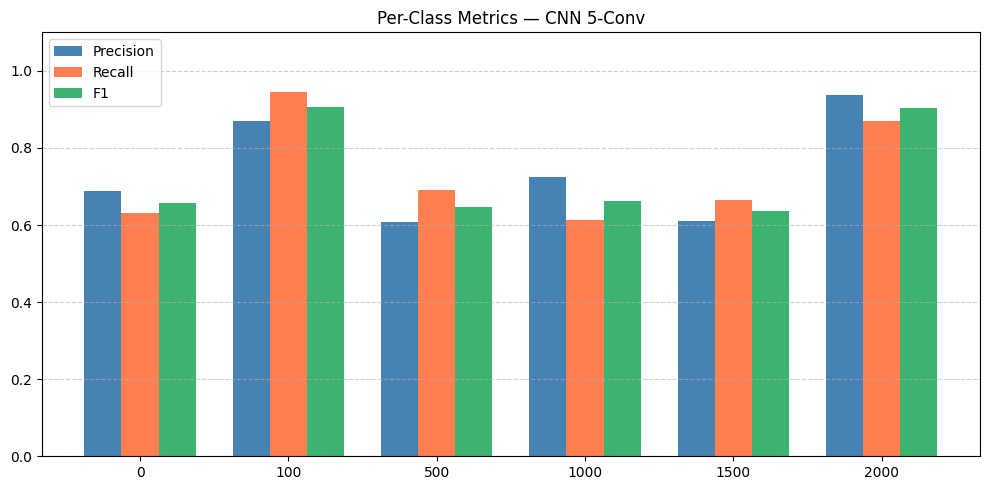

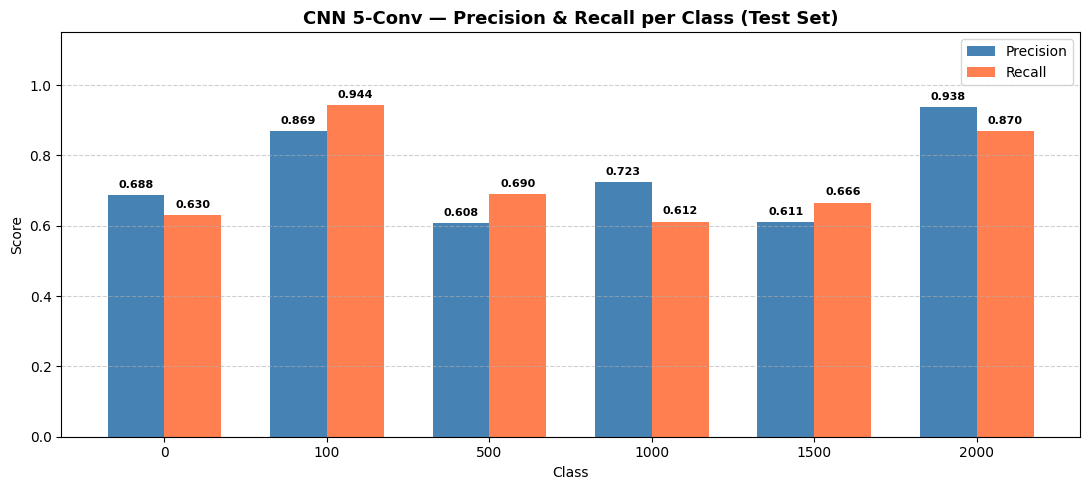

CNN Precision & Recall chart saved.


/tmp/ipykernel_29116/306566726.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_29116/306566726.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



CNN 5-Conv — Inference Time (100 random samples)
  Average : 0.900 ms / sample
  Std Dev : 0.100 ms
  Min     : 0.768 ms
  Max     : 1.429 ms
CNN inference times saved.


In [5]:
# ================================================
# Cell 5 — CNN Test Evaluation + Inference Print
# ================================================
import time

# Load best checkpoint (lowest val_loss) for evaluation
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct   = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (CNN 5-Conv): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# Confusion matrix across all 6 milling classes
# ── Confusion Matrix ──
cm   = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — CNN 5-Conv")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_cnn.png"), dpi=150)
plt.show()


# Per-class precision, recall, F1 — saved as .txt and .csv
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — CNN 5-Conv:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_cnn.txt"), "w") as f:
    f.write(report_txt)
pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, "classification_report_cnn.csv"))


# Grouped bar charts: Precision / Recall / F1 per class
# ── Per-class metrics ──
cnn_precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
cnn_recall    = recall_score(all_labels,    all_preds, average=None, labels=range(NUM_CLASSES))
cnn_f1        = f1_score(all_labels,        all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, cnn_precision, w, label='Precision', color='steelblue')
plt.bar(x,     cnn_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, cnn_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — CNN 5-Conv")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_cnn.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, cnn_precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, cnn_recall,    w2, label='Recall',    color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, cnn_precision[i] + 0.02, f'{cnn_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, cnn_recall[i]    + 0.02, f'{cnn_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 5-Conv — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_cnn.png"), dpi=150)
plt.show()
print("CNN Precision & Recall chart saved.")


# Per-sample true label, predicted label, correct flag
# ── Raw predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct":    (all_preds == all_labels).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, "predictions_cnn.csv"), index=False)

# ================================================
# CNN Inference Time — 100 random test samples
# ================================================
_rng100        = np.random.RandomState(SEED)
_sample_idx    = _rng100.choice(len(test_ds), 100, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0)

with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    with torch.cuda.amp.autocast():
        _ = model(_warm.to(DEVICE))
torch.cuda.synchronize()

cnn_times_ms = []
model.eval()
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast():
            _ = model(_inp)
        torch.cuda.synchronize()
        cnn_times_ms.append((time.perf_counter() - _t0) * 1000)

cnn_avg_time_ms = float(np.mean(cnn_times_ms))
cnn_std_time_ms = float(np.std(cnn_times_ms))

print("\n" + "="*52)
print("CNN 5-Conv — Inference Time (100 random samples)")
print("="*52)
print(f"  Average : {cnn_avg_time_ms:.3f} ms / sample")
print(f"  Std Dev : {cnn_std_time_ms:.3f} ms")
print(f"  Min     : {np.min(cnn_times_ms):.3f} ms")
print(f"  Max     : {np.max(cnn_times_ms):.3f} ms")
print("="*52)

pd.DataFrame({"sample": range(100), "cnn_time_ms": cnn_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "cnn_inference_times.csv"), index=False)
print("CNN inference times saved.")

In [6]:
# ================================================
# Cell 6 — Feature Extraction  (save embeddings)
# ================================================
# ── Feature extraction ─────────────────────────────────────────
# Extracts 256-d embeddings (fc1 bottleneck output, not 512-d backbone).
# Saved as .npy for mRMR (K=64), SVM training, and PCA.
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE)
            with torch.cuda.amp.autocast():
                _, emb = model(inputs, return_embedding=True)  # (B, 128)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

train_embs, train_y = extract_embeddings(train_loader, model, "train")
val_embs,   val_y   = extract_embeddings(val_loader,   model, "val")
test_embs,  test_y  = extract_embeddings(test_loader,  model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [("train_embs", train_embs), ("val_embs",  val_embs),
                  ("test_embs",  test_embs),  ("train_y",   train_y),
                  ("val_y",      val_y),       ("test_y",    test_y)]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")

Extracting [train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_29116/3616339946.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Extracting [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding shapes -> train: (10500, 256)  val: (1500, 256)  test: (3000, 256)
  Saved train_embs.npy  shape=(10500, 256)
  Saved val_embs.npy  shape=(1500, 256)
  Saved test_embs.npy  shape=(3000, 256)
  Saved train_y.npy  shape=(10500,)
  Saved val_y.npy  shape=(1500,)
  Saved test_y.npy  shape=(3000,)

All embeddings saved.


Running mRMR: 12000 samples, 256 features -> selecting K=64 ...


/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 10 selected features (by MI):
 feature_index       mi
           201 0.828243
            16 0.818860
           157 0.817108
            53 0.813033
            24 0.808058
           237 0.802663
            40 0.794997
            64 0.786773
            41 0.770734
           247 0.763585


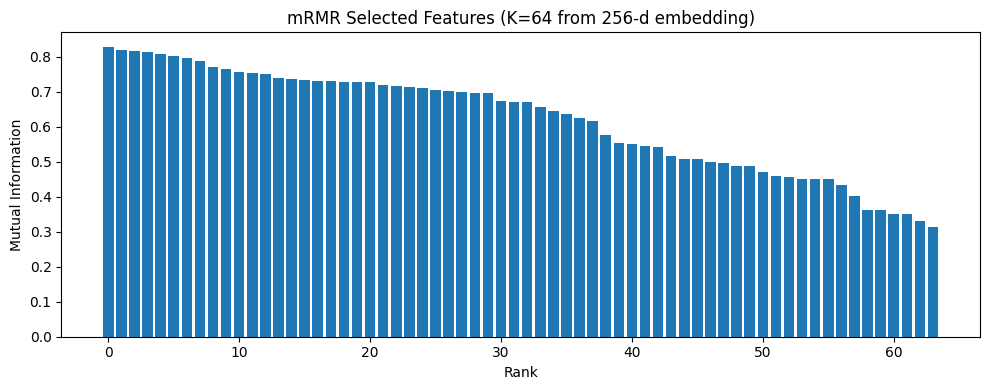

Reduced embedding: 64-d


In [7]:
# ================================================
# Cell 7 — mRMR Feature Selection
# ================================================
# ── mRMR greedy feature selection ──────────────────────────────
# Selects K=64 features from the 256-d embedding.
# Greedy: maximise MI(feature, label) minus mean correlation
# with already-selected features. Fitted on train+val.
def mrmr_select(X, y, k, seed=SEED):
    """
    Greedy mRMR:
      relevance  = MI(feature, label)
      redundancy = mean |corr| to already-selected features
      score      = relevance - redundancy
    """
    X, y = np.asarray(X), np.asarray(y)
    k    = min(k, X.shape[1])
    mi   = mutual_info_classif(X, y, random_state=seed, discrete_features=False)
    corr = np.nan_to_num(np.abs(np.corrcoef(X, rowvar=False)), nan=0.0)

    selected  = [int(np.argmax(mi))]
    candidate = set(range(X.shape[1])) - set(selected)

    while len(selected) < k and candidate:
        scores    = {f: mi[f] - np.mean(corr[f, selected]) for f in candidate}
        best_feat = max(scores, key=scores.get)
        selected.append(best_feat)
        candidate.remove(best_feat)

    return selected, mi


# Combine train+val for more reliable MI estimation
X_tv = np.vstack([train_embs, val_embs])
y_tv = np.hstack([train_y,   val_y])

print(f"Running mRMR: {X_tv.shape[0]} samples, {X_tv.shape[1]} features -> selecting K={K_MRMR} ...")
selected_idx, mi = mrmr_select(X_tv, y_tv, k=K_MRMR)

sel_df = (pd.DataFrame({"feature_index": selected_idx, "mi": mi[selected_idx]})
            .sort_values("mi", ascending=False).reset_index(drop=True))
sel_df.to_csv(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}.csv"), index=False)

print(f"\nTop 10 selected features (by MI):")
print(sel_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(range(len(selected_idx)), sel_df["mi"].values)
plt.xlabel("Rank"); plt.ylabel("Mutual Information")
plt.title(f"mRMR Selected Features (K={K_MRMR} from 256-d embedding)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}_plot.png"), dpi=150)
plt.show()


# Reduce 256-d to 64-d using mRMR-selected indices
train_sel = train_embs[:, selected_idx]
val_sel   = val_embs[:,   selected_idx]
test_sel  = test_embs[:,  selected_idx]
print(f"Reduced embedding: {train_sel.shape[1]}-d")

Training SVM (RBF, C=10) ...
SVM training done.

SVM INFERENCE — per sample
     #    True Label    Pred Label   Correct
     0             0             0       YES
     1             0             0       YES
     2             0           500       NO 
     3             0             0       YES
     4             0             0       YES
     5             0           500       NO 
     6             0             0       YES
     7             0             0       YES
     8             0             0       YES
     9             0             0       YES
    10             0             0       YES
    11             0           500       NO 
    12             0             0       YES
    13             0             0       YES
    14             0           500       NO 
    15             0             0       YES
    16             0           500       NO 
    17             0             0       YES
    18             0             0       YES
    19             0    

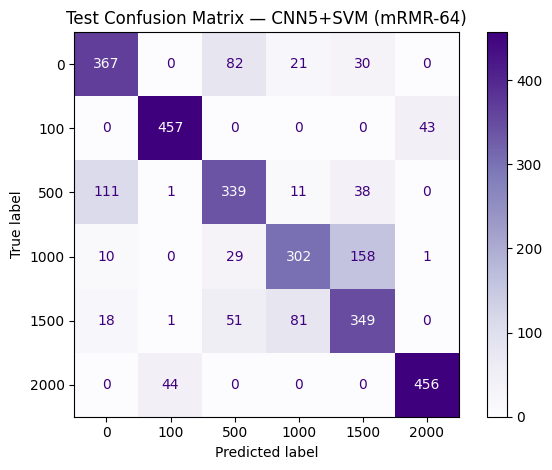


Classification Report — CNN5+SVM (mRMR-64):
              precision    recall  f1-score   support

           0     0.7253    0.7340    0.7296       500
         100     0.9085    0.9140    0.9113       500
         500     0.6766    0.6780    0.6773       500
        1000     0.7277    0.6040    0.6601       500
        1500     0.6070    0.6980    0.6493       500
        2000     0.9120    0.9120    0.9120       500

    accuracy                         0.7567      3000
   macro avg     0.7595    0.7567    0.7566      3000
weighted avg     0.7595    0.7567    0.7566      3000



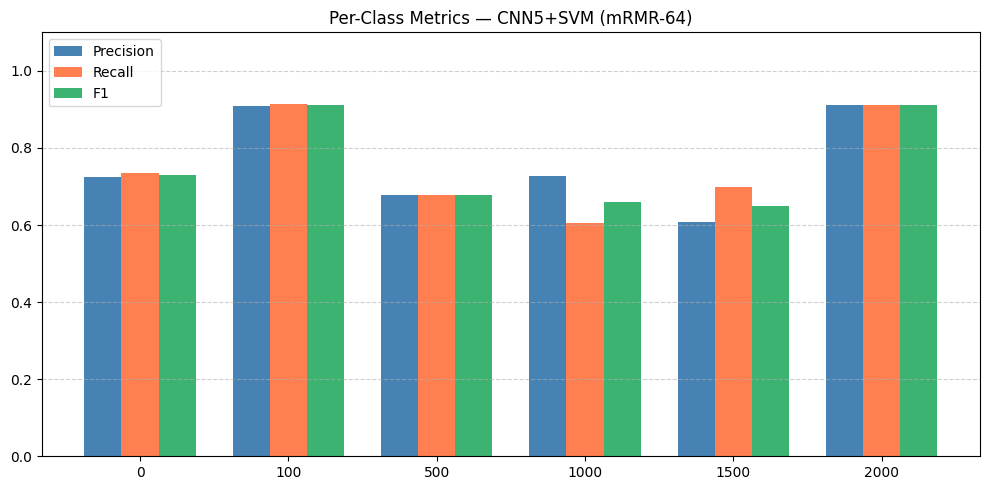

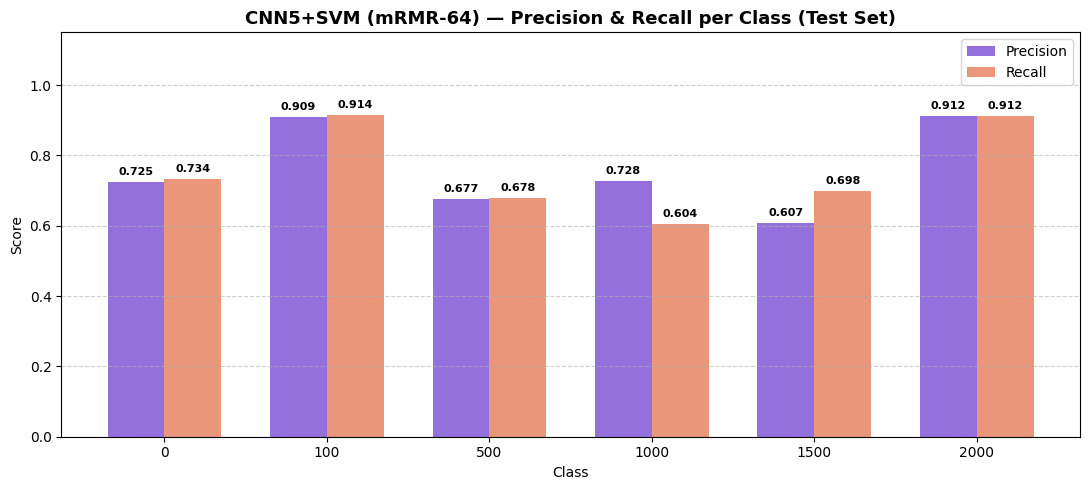

SVM Precision & Recall chart saved.


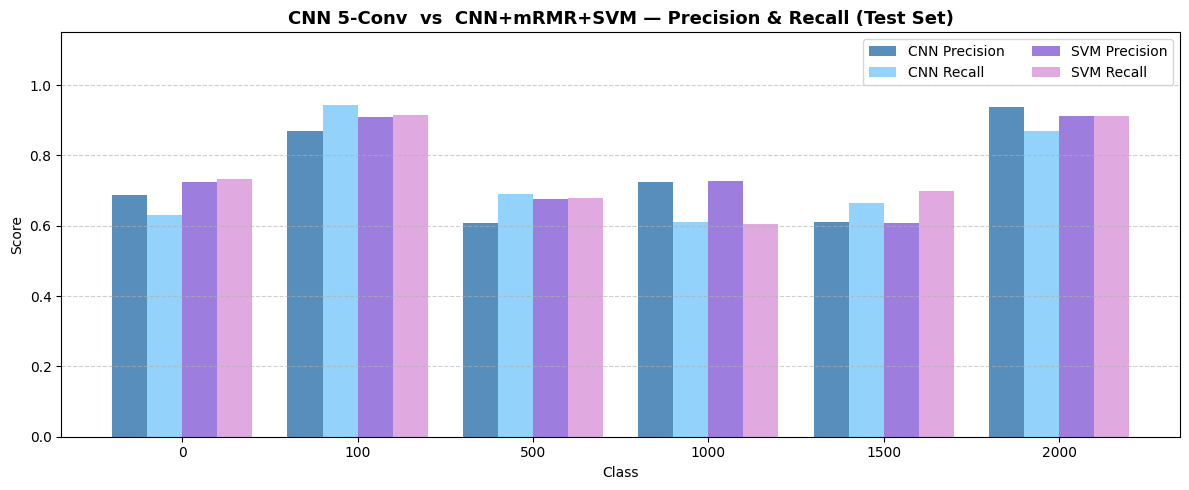

CNN vs SVM comparison chart saved.

SVM (mRMR-64) — Inference Time (100 random samples)
  Average : 0.4681 ms / sample
  Std Dev : 0.0291 ms
  Min     : 0.4278 ms
  Max     : 0.6118 ms

INFERENCE TIME SUMMARY (avg over 100 samples)
  CNN alone        : 0.900 ± 0.100 ms
  SVM alone (mRMR) : 0.4681 ± 0.0291 ms
  Full pipeline    : 1.368 ms  (CNN + SVM)

All artifacts saved in: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN5_May11_Results
best_custom_5cnn_model.pth
classification_report_cnn.csv
classification_report_cnn.txt
classification_report_svm_mrmr_64.csv
classification_report_svm_mrmr_64.txt
cnn_inference_times.csv
comparison_cnn_vs_svm_precision_recall.png
confusion_matrix_cnn.png
confusion_matrix_svm_mrmr_64.png
inference_time_summary.csv
mrmr_selected_64.csv
mrmr_selected_64_plot.png
per_class_metrics_cnn.png
per_class_metrics_svm_mrmr_64.png
precision_recall_cnn.png
precision_recall_svm_mrmr_64.png
predictions_cnn.csv
predictions_svm_mrmr_64.csv
scaler_mrmr_svm.joblib

In [8]:
# ================================================
# Cell 8 — SVM Training + Evaluation + Inference
# ================================================
# ── SVM pipeline ───────────────────────────────────────────────
# StandardScaler normalises 64-d mRMR features before SVM.
# Fitted on train+val; applied to test only (no leakage).
scaler       = StandardScaler()
train_std    = scaler.fit_transform(np.vstack([train_sel, val_sel]))
test_std     = scaler.transform(test_sel)
y_train_full = np.hstack([train_y, val_y])

print("Training SVM (RBF, C=10) ...")
svm = SVC(kernel="rbf", C=10.0, gamma="scale", probability=False, random_state=SEED)
svm.fit(train_std, y_train_full)
print("SVM training done.")


# Save scaler and SVM for future inference
dump(scaler, os.path.join(OUTPUT_DIR, "scaler_mrmr_svm.joblib"))
dump(svm,    os.path.join(OUTPUT_DIR, "svm_mrmr_rbf.joblib"))


# Run SVM predictions on the full test set
# ── SVM Inference per sample ──
svm_preds = svm.predict(test_std)

print("\n" + "="*65)
print("SVM INFERENCE — per sample")
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)
for i, (true, pred) in enumerate(zip(test_y, svm_preds)):
    correct = "YES" if true == pred else "NO "
    print(f"{i:>6}  {CLASS_NAMES[true]:>12}  {CLASS_NAMES[pred]:>12}  {correct:>8}")
print("="*65)

svm_acc = (svm_preds == test_y).mean()
print(f"\nTest Accuracy (CNN5 + mRMR-{K_MRMR} + SVM): {svm_acc * 100:.2f}%")
print(f"Correct: {(svm_preds == test_y).sum()} / {len(test_y)}")


# Confusion matrix across all 6 milling classes
# ── Confusion Matrix ──
cm_svm = confusion_matrix(test_y, svm_preds, labels=list(range(NUM_CLASSES)))
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=CLASS_NAMES)
disp.plot(cmap='Purples', values_format='d')
plt.title(f"Test Confusion Matrix — CNN5+SVM (mRMR-{K_MRMR})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()


# Per-class precision, recall, F1 — saved as .txt and .csv
# ── Classification Report ──
rep_txt = classification_report(test_y, svm_preds, target_names=CLASS_NAMES, digits=4)
print(f"\nClassification Report — CNN5+SVM (mRMR-{K_MRMR}):")
print(rep_txt)
with open(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.txt"), "w") as f:
    f.write(rep_txt)
pd.DataFrame(
    classification_report(test_y, svm_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.csv"))


# Grouped bar charts: Precision / Recall / F1 per class
# ── Per-class metrics ──
svm_precision = precision_score(test_y, svm_preds, average=None, labels=range(NUM_CLASSES))
svm_recall    = recall_score(test_y,    svm_preds, average=None, labels=range(NUM_CLASSES))
svm_f1        = f1_score(test_y,       svm_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 (SVM) ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, svm_precision, w, label='Precision', color='steelblue')
plt.bar(x,     svm_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, svm_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title(f"Per-Class Metrics — CNN5+SVM (mRMR-{K_MRMR})")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"per_class_metrics_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart (SVM) ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, svm_precision, w2, label='Precision', color='mediumpurple')
plt.bar(x + w2/2, svm_recall,    w2, label='Recall',    color='darksalmon')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, svm_precision[i] + 0.02, f'{svm_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, svm_recall[i]    + 0.02, f'{svm_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title(f"CNN5+SVM (mRMR-{K_MRMR}) — Precision & Recall per Class (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"precision_recall_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()
print("SVM Precision & Recall chart saved.")


# CNN vs SVM comparison: grouped precision/recall per class
# ── Chart 3: CNN vs SVM comparison (Precision & Recall same chart) ──
w3 = 0.2
plt.figure(figsize=(12, 5))
plt.bar(x - 1.5*w3, cnn_precision, w3, label='CNN Precision',     color='steelblue',    alpha=0.9)
plt.bar(x - 0.5*w3, cnn_recall,    w3, label='CNN Recall',        color='lightskyblue', alpha=0.9)
plt.bar(x + 0.5*w3, svm_precision, w3, label='SVM Precision',     color='mediumpurple', alpha=0.9)
plt.bar(x + 1.5*w3, svm_recall,    w3, label='SVM Recall',        color='plum',         alpha=0.9)
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 5-Conv  vs  CNN+mRMR+SVM — Precision & Recall (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(ncol=2); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_cnn_vs_svm_precision_recall.png"), dpi=150)
plt.show()
print("CNN vs SVM comparison chart saved.")

# ── Predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(test_y)),
    "True Label": [CLASS_NAMES[i] for i in test_y],
    "Pred Label": [CLASS_NAMES[i] for i in svm_preds],
    "Correct":    (svm_preds == test_y).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, f"predictions_svm_mrmr_{K_MRMR}.csv"), index=False)

# ================================================
# SVM Inference Time — same 100 random test samples
# ================================================
_rng100     = np.random.RandomState(SEED)
_sample_idx = _rng100.choice(len(test_y), 100, replace=False)
_test_100   = test_std[_sample_idx]

_ = svm.predict(_test_100[:1])   # warm-up

svm_times_ms = []
for i in range(100):
    _t0 = time.perf_counter()
    _   = svm.predict(_test_100[i : i + 1])
    svm_times_ms.append((time.perf_counter() - _t0) * 1000)

svm_avg_time_ms = float(np.mean(svm_times_ms))
svm_std_time_ms = float(np.std(svm_times_ms))

print("\n" + "="*55)
print(f"SVM (mRMR-{K_MRMR}) — Inference Time (100 random samples)")
print("="*55)
print(f"  Average : {svm_avg_time_ms:.4f} ms / sample")
print(f"  Std Dev : {svm_std_time_ms:.4f} ms")
print(f"  Min     : {np.min(svm_times_ms):.4f} ms")
print(f"  Max     : {np.max(svm_times_ms):.4f} ms")
print("="*55)

pd.DataFrame({"sample": range(100), "svm_time_ms": svm_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, f"svm_inference_times_{K_MRMR}.csv"), index=False)


# Inference time: CNN alone / SVM alone / full pipeline
# ── Final Summary ──
pipeline_avg = cnn_avg_time_ms + svm_avg_time_ms
print("\n" + "="*55)
print("INFERENCE TIME SUMMARY (avg over 100 samples)")
print("="*55)
print(f"  CNN alone        : {cnn_avg_time_ms:.3f} ± {cnn_std_time_ms:.3f} ms")
print(f"  SVM alone (mRMR) : {svm_avg_time_ms:.4f} ± {svm_std_time_ms:.4f} ms")
print(f"  Full pipeline    : {pipeline_avg:.3f} ms  (CNN + SVM)")
print("="*55)

pd.DataFrame({
    "Stage":   ["CNN only", f"SVM mRMR-{K_MRMR}", "Full Pipeline"],
    "Avg_ms":  [round(cnn_avg_time_ms, 4), round(svm_avg_time_ms, 4), round(pipeline_avg, 4)],
    "Std_ms":  [round(cnn_std_time_ms, 4), round(svm_std_time_ms, 4), "-"],
}).to_csv(os.path.join(OUTPUT_DIR, "inference_time_summary.csv"), index=False)

print("\n" + "="*50)
print("All artifacts saved in:", OUTPUT_DIR)
print("="*50)
print(os.linesep.join(sorted(os.listdir(OUTPUT_DIR))))

Embeddings : (3000, 256)
True labels: (3000,)
Classes    : ['0', '100', '500', '1000', '1500', '2000']
PCA output : /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN5_May11_Results/PCA_Analysis

Explained variance: PC1=0.710  PC2=0.142  Total=0.852


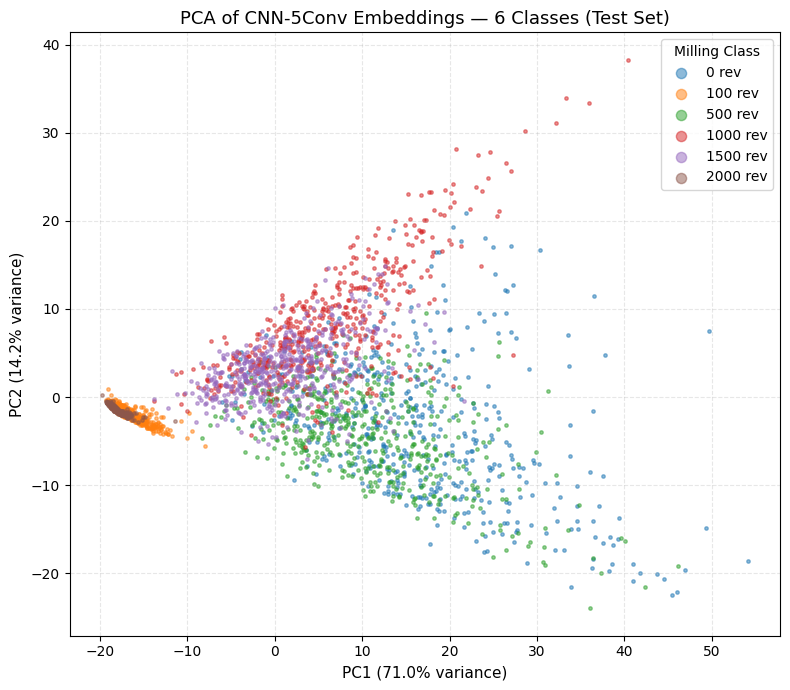

Saved: pca_embeddings.png


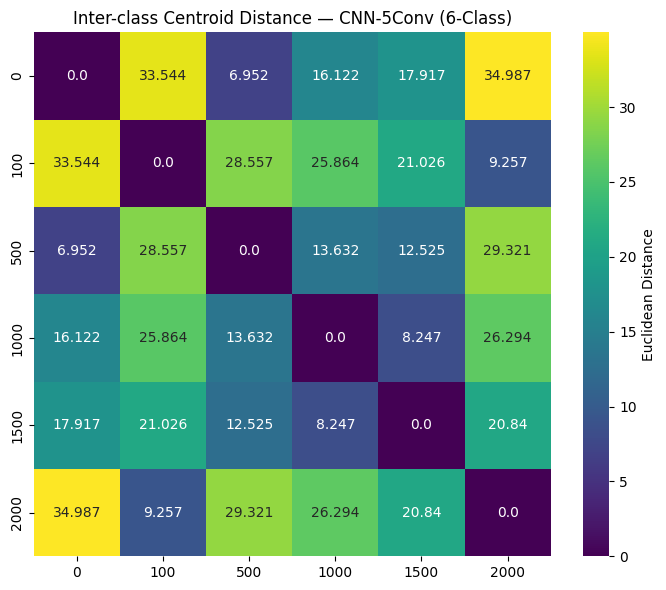

Saved: distance_heatmap.png


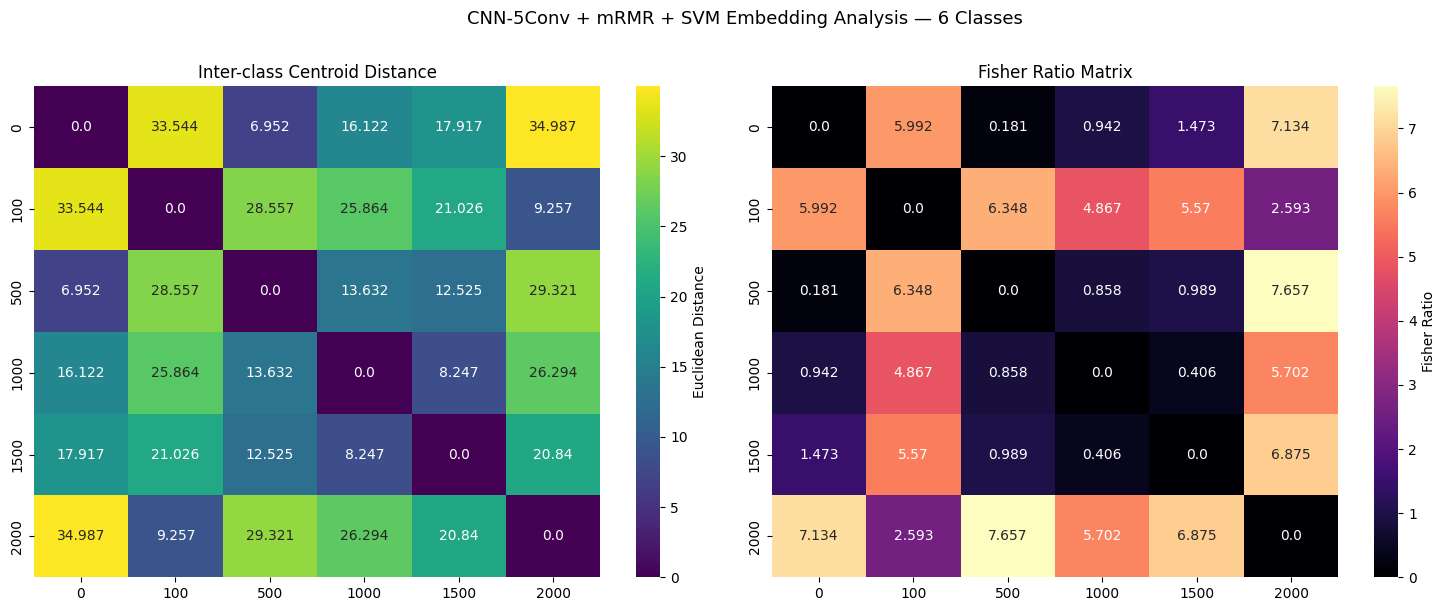

Saved: distance_fisher_side_by_side.png


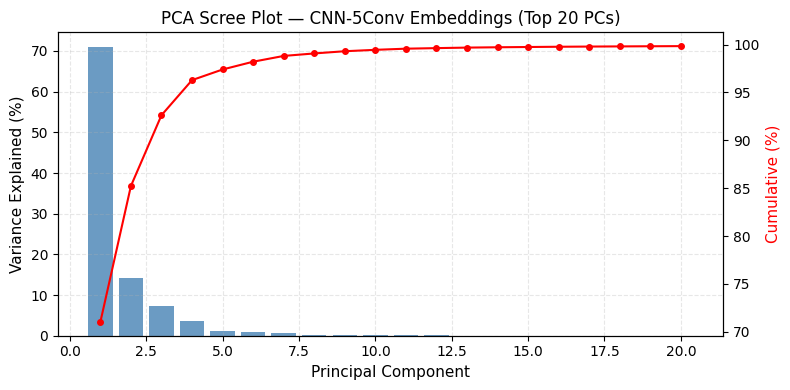

Saved: pca_scree_plot.png

All PCA results saved to: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN5_May11_Results/PCA_Analysis
PC1+PC2 explains : 85.2%
PCs for 95% var  : 4


In [9]:
# ================================================
# Cell 9 — PCA Analysis of CNN Embeddings
# ================================================
# seaborn/scipy/sklearn PCA: heatmaps, centroid distances, 2D projection
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from glob import glob

PCA_DIR = os.path.join(OUTPUT_DIR, "PCA_Analysis")
os.makedirs(PCA_DIR, exist_ok=True)


# Load 256-d CNN embeddings for PCA (raw fc1 output, not mRMR-reduced)
# Load CNN embeddings saved by Cell 6
test_embs = np.load(os.path.join(OUTPUT_DIR, "test_embs.npy"))
y_true    = np.load(os.path.join(OUTPUT_DIR, "test_y.npy"))

# Find predictions CSV (SVM predictions saved by Cell 8)
pred_csvs = glob(os.path.join(OUTPUT_DIR, "predictions_*.csv"))
assert pred_csvs, f"No predictions CSV found in {OUTPUT_DIR}. Run Cell 8 first."
pred_df      = pd.read_csv(pred_csvs[0])
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
y_pred = np.array([label_to_idx[str(l)] for l in pred_df["Pred Label"].values])

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'][:NUM_CLASSES]

print(f"Embeddings : {test_embs.shape}")
print(f"True labels: {y_true.shape}")
print(f"Classes    : {CLASS_NAMES}")
print(f"PCA output : {PCA_DIR}")


# ── PCA 2-D projection ─────────────────────────────────────────
# Projects 256-d embeddings to 2 PCs.
# Deeper features (5-layer) expected to show better cluster
# separation than CNN2-CNN4 despite similar embedding dimension.
# ── PCA 2D scatter ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(test_embs)
var = pca.explained_variance_ratio_
print(f"\nExplained variance: PC1={var[0]:.3f}  PC2={var[1]:.3f}  Total={var.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i, name in enumerate(CLASS_NAMES):
    idx = (y_true == i)
    ax.scatter(Z[idx, 0], Z[idx, 1], s=6, alpha=0.5, label=f'{name} rev', color=COLORS[i])
ax.set_title(f'PCA of CNN-5Conv Embeddings — {NUM_CLASSES} Classes (Test Set)', fontsize=13)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', fontsize=11)
ax.legend(markerscale=3, fontsize=10, title='Milling Class')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_embeddings.png"), dpi=300)
plt.show()
print("Saved: pca_embeddings.png")


# Inter-class centroid Euclidean distances in 256-d embedding space
# ── Centroid distances ──────────────────────────
centroids, intra_spread = [], []
for i in range(NUM_CLASSES):
    Xc = test_embs[y_true == i]
    mu = Xc.mean(axis=0)
    centroids.append(mu)
    intra_spread.append(np.mean(np.linalg.norm(Xc - mu, axis=1)))
centroids    = np.vstack(centroids)
intra_spread = np.array(intra_spread)

inter   = cdist(centroids, centroids, metric='euclidean')
dist_df = pd.DataFrame(inter, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title(f'Inter-class Centroid Distance — CNN-5Conv ({NUM_CLASSES}-Class)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_heatmap.png"), dpi=300)
plt.show()
print("Saved: distance_heatmap.png")


# Fisher ratio + distance heatmaps side by side for paper figure
# ── Fisher ratio + side-by-side ─────────────────
intra_var = intra_spread ** 2
F = np.zeros((NUM_CLASSES, NUM_CLASSES))
for a in range(NUM_CLASSES):
    for b in range(NUM_CLASSES):
        if a != b:
            F[a, b] = (inter[a, b] ** 2) / (intra_var[a] + intra_var[b] + 1e-8)
fish_df = pd.DataFrame(F, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'Euclidean Distance'})
axes[0].set_title('Inter-class Centroid Distance', fontsize=12)
sns.heatmap(fish_df.round(3), annot=True, fmt='', cmap='magma', ax=axes[1],
            cbar_kws={'label': 'Fisher Ratio'})
axes[1].set_title('Fisher Ratio Matrix', fontsize=12)
fig.suptitle(f'CNN-5Conv + mRMR + SVM Embedding Analysis — {NUM_CLASSES} Classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_fisher_side_by_side.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: distance_fisher_side_by_side.png")


# PCA scree: variance per component and cumulative variance
# ── Scree plot ──────────────────────────────────
pca_full = PCA(random_state=42).fit(test_embs)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax  = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100, color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(range(1, 21), cum_var[:20]*100, color='red', marker='o', ms=4)
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_ylabel('Cumulative (%)', fontsize=11, color='red')
ax.set_title('PCA Scree Plot — CNN-5Conv Embeddings (Top 20 PCs)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_scree_plot.png"), dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")


# Export PCA metrics to CSV for reproducibility
# ── Save CSVs ───────────────────────────────────
dist_df.to_csv(os.path.join(PCA_DIR, "pairwise_centroid_distance.csv"))
fish_df.to_csv(os.path.join(PCA_DIR, "pairwise_fisher_ratio.csv"))
pd.DataFrame({'Class': CLASS_NAMES, 'Intra_spread': intra_spread.round(4),
              'N_samples': [int(np.sum(y_true == i)) for i in range(NUM_CLASSES)]
}).to_csv(os.path.join(PCA_DIR, "class_spread_summary.csv"), index=False)
pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
              'True_Label': [CLASS_NAMES[i] for i in y_true]
}).to_csv(os.path.join(PCA_DIR, "pca_coordinates.csv"), index=False)

n_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"\nAll PCA results saved to: {PCA_DIR}")
print(f"PC1+PC2 explains : {cum_var[1]*100:.1f}%")
print(f"PCs for 95% var  : {n_95}")